In [4]:
import time
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
import cv2
import time


import torch
from torch import nn
import copy
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2

from IPython.display import clear_output
import matplotlib.colors as mcolors
from scipy.ndimage import label
from skimage.segmentation import watershed
from torchvision.utils import make_grid

from Ellipses import *
from plottings import *
from metrics import *
from GRU import *
from gallery_of_failures import *

from load_dataset import *
from rastreadores import *
from treino_gru import *
from utils_mot import *
from sinteticos import *
import os; os.makedirs("checkpoints", exist_ok=True)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parte 0

In [5]:
ellipses_sim = EllipsesSimulator(img_size=128, num_obj=8, dur_occlusion=12, speed=1,
                                 noise_std=15, contrast=1.0, n_occlusions=1, seed=0)
frames, ground_truth = ellipses_sim.simulate(60)
frames_with_bboxes = visualize_ground_truth(frames, ground_truth)
print(ellipses_sim.occlusion_events)

[{'target_id': 6, 'occluder_id': 7, 'start': 20, 'end': 31, 'dur': 12}]


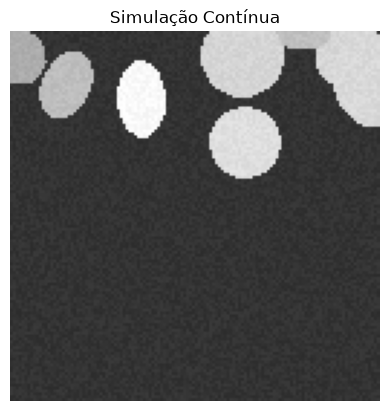

In [6]:
plot_simulation_frames(frames)

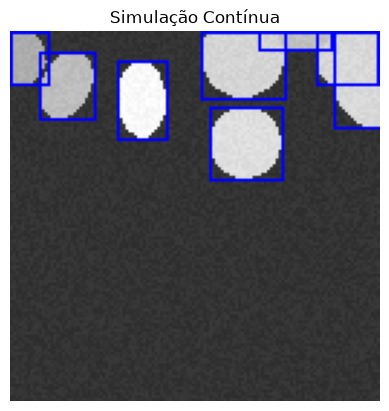

In [8]:
plot_simulation_frames(frames_with_bboxes)

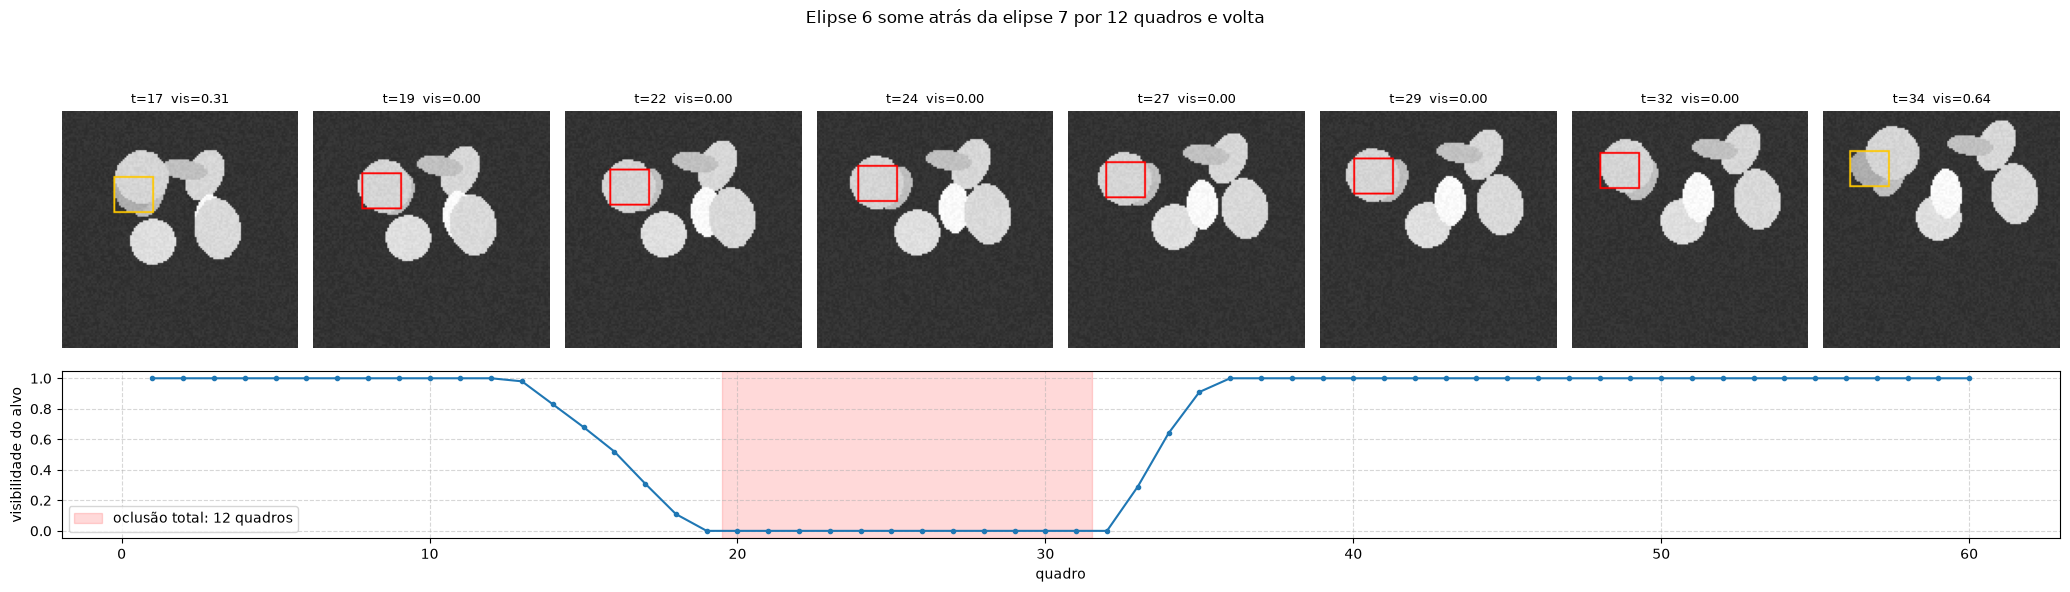

In [9]:
plot_occlusion_event(frames, ground_truth, ellipses_sim.occlusion_events[0], salvar="fig_oclusao.png")

In [10]:
frames_with_noisy_bboxes, noisy_annotations = create_noisy_bboxes(
    frames, ground_truth, percentage=0.1, fp_rate=0.05, vis_min=0.3)

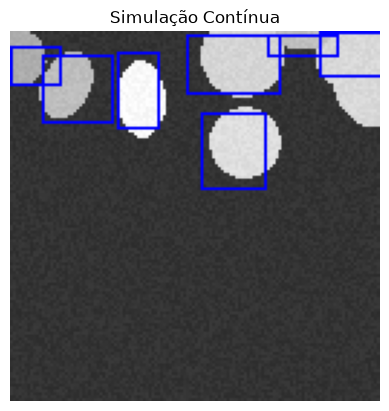

In [12]:
plot_simulation_frames(frames_with_noisy_bboxes)

In [13]:
run_metric_tests()

(a) pred = GT          : IDF1 = 1.0000 | switches = 0
(b) 2 IDs trocados k=11: IDF1 = 0.6667 (esperado 0.6667) | switches = 2 (esperado 2)
(c) track partida  k=11: IDF1 = 0.8333 (esperado 0.8333) | switches = 1 (esperado 1)
Todos os asserts passaram.


({'IDF1 Score': 1.0,
  'ID Switches': 0,
  'Fragmentacoes': 0,
  'Erro de Contagem de IDs': 0,
  'Track History': {np.float64(1.0): [1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1],
   np.float64(2.0): [1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1],
   np.float64(3.0): [1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1]}},
 {'IDF1 Score': 0.6666666666666666,
  'ID Switches': 2,
  'Fragmentacoes': 0,
  'Erro de Contagem de IDs': 0,
  'Track History': {np.float64(1.0): [1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1],
   np.float64(2.0): [1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1

Piso fácil (3 elipses, speed=0.5, sem oclusão), 20 seeds:
  IDF1 = 0.9921 ± 0.0290 | switches médios = 0.00


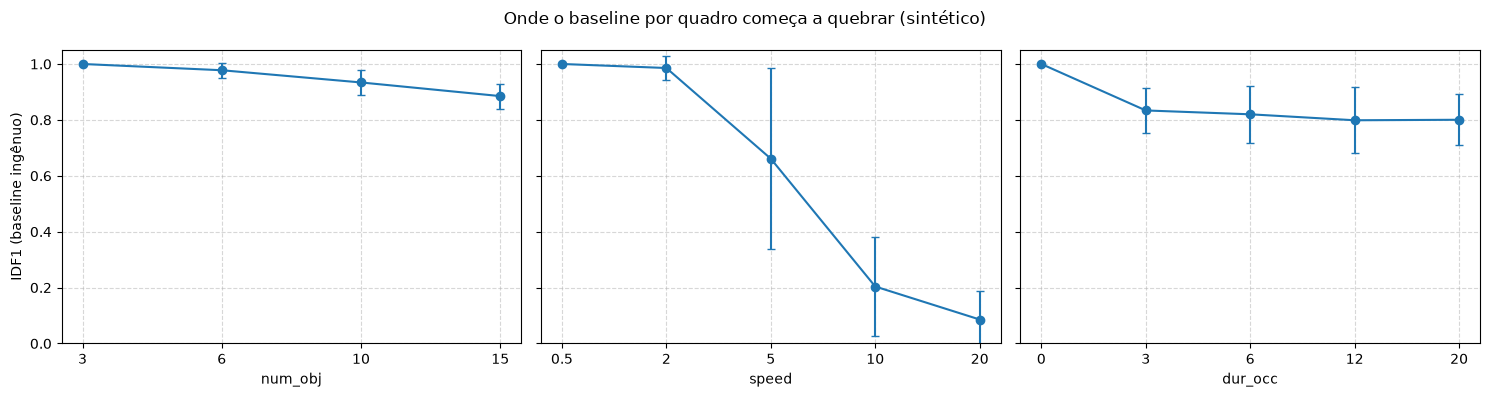

In [14]:
baseline_piso_facil(n_seeds=20)          # IDF1 ≈ 0.99

res = {
  'num_obj': varrer('num_obj', [3, 6, 10, 15], n_seeds=10),
  'speed':   varrer('speed',   [0.5, 2, 5, 10, 20], n_seeds=10),
  'dur_occ': varrer('dur_occ', [0, 3, 6, 12, 20], n_seeds=10),
}
plot_varreduras(res)

# Parte 1

In [15]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def desnorm(img, mean=MEAN, std=STD):
    img_plot = img.cpu().permute(1, 2, 0).numpy()
    mean = np.array(mean)
    std = np.array(std)
    img_plot = (img_plot * std) + mean
    return np.clip(img_plot, 0, 1)

# Pipeline para redimensionamento das imagens
train_transform = A.Compose([
    # # Forca image e mask para 256x256
    # A.Resize(height=256, width=256),

    # # Padroniza o espectro de cores como cinza
    # A.ToGray(p=1.0),

    # # Normaliza os pixels para o padrao ImageNet
    # A.Normalize(mean=MEAN, std=STD),

    # Converte os arrays Numpy para Tensores do PyTorch e ajusta as dimensoes ((H, W, C) ==> (C, H, W))
    ToTensorV2()
])

batch_size = 1


# Definindo as sequencias para cada split
# Sao os numeros dos videos do dataset de treino oficial
train_videos = [2, 4, 5, 9, 10]
val_videos = [11, 13]

# Cria o Dataset de Treino (80% dos videos, ordem cronologica)
train_dataset = MOT17Dataset(
    root="features",
    model_base="SDP",
    sequences_list=train_videos,
    transform=train_transform,
    train_dataset=True
)

# Cria o Dataset de Validação (20% dos videos, ordem cronologica)
val_dataset = MOT17Dataset(
    root="features",
    model_base="SDP",
    sequences_list=val_videos,
    transform=train_transform,
    train_dataset=True  # Mantem True para carregar os GTs para calcular as metricas!
)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

In [16]:
current_seq = None

frames_by_video = {}
ground_truth_SDP_by_video = {}
dets_SDP_by_video = {}
frames = []
ground_truth_SDP = []
dets_SDP = []
for batch_idx, (images, dets, gts, seq_names, frame_ids) in enumerate(train_loader):
    # O DataLoader insere uma dimensao extra por causa do batch. Extraimos aqui:
    image = images.squeeze(0)        # Formato final: [3, H, W]
    det = dets.squeeze(0)            # Formato final: [Num_Deteccoes, 5]
    gt = gts.squeeze(0)              # Formato final: [Num_Pessoas_Reais, 4]
    
    seq_name = seq_names[0]          # Extrai a string
    frame_id = frame_ids[0].item()   # Extrai o número do frame
    
    # --- DETECTOR DE MUDANÇA DE VIDEO ---
    if seq_name != current_seq:
        # Se tiver terminado um video valido, arquiva os dados dele
        if not current_seq is None:
            frames_by_video[current_seq] = frames
            ground_truth_SDP_by_video[current_seq] = ground_truth_SDP
            dets_SDP_by_video[current_seq] = dets_SDP
            # break # Salva so o primeiro video

        frames = []
        ground_truth_SDP = []
        dets_SDP = []
        current_seq = seq_name
    elif len(frames) >= 50: continue # Salva somente os 50 primeiros frames
    
    frames.append(image.permute(1, 2, 0).numpy())
    gts_str = [
        ', '.join([
            *(row[:-1].int()).numpy().astype(str).tolist(),
            row[-1].numpy().astype(str).tolist()
        ])
        for row in gts[0]
    ]
    ground_truth_SDP.extend(gts_str)
    dets_str = [
        ', '.join([
            *(row[:-1].int()).numpy().astype(str).tolist(),
            row[-1].numpy().astype(str).tolist()
        ])
        for row in dets[0]
    ]
    dets_SDP.extend(dets_str)

In [17]:
def collate_fn(batch):
    """
    Agrupa os dados do batch numa tupla de listas.
    O batch recebe a saída do nosso __getitem__: (image, dets, gts, seq_name, frame_id)
    """
    return tuple(zip(*batch))

In [18]:
import torch
import torchvision
from torch.utils.data import DataLoader

# --- 1. CONFIGURACOES ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
MIN_CONFIDENCE = 0.5  # So aceita predicoes com mais de 50% de certeza

# Instancia o DataLoader (batch_size=1, shuffle=False para processar na ordem)
data_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

# --- 2. CARREGAR MODELO PRE-TREINADO ---
print("Carregando Faster R-CNN pre-treinado...")
model_rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights='DEFAULT',
    box_score_thresh=0.5, # Filtra a confiança nativamente (padrão é 0.05)
    box_nms_thresh=0.5 # Deixa o NMS mais rigoroso (padrão é 0.5)
)
model_rcnn.to(device)
model_rcnn.eval()  # MODO INFERENCIA: Desliga calculo de gradientes e congela camadas (Dropout/BatchNorm)

# Dicionario para guardar as novas deteccoes: dict[seq_name][frame_id] = [bboxes]
novas_deteccoes = {}

print("Iniciando inferencia...")
# --- 3. LOOP DE INFERENCIA ---
with torch.no_grad():
    for batch_idx, (images, dets_publicas, gts, seq_names, frame_ids) in enumerate(data_loader):
        if len(novas_deteccoes.get(seq_names[0], [])) >= 50: continue # Salva somente os 50 primeiros frames de cada video
        # if seq_names[0] != "MOT17-02-SDP": continue # Salva só o primeiro video
        # O DataLoader com collate_fn entrega tuplas. Vamos pegar o primeiro elemento (batch 1)
        image = (images[0] / 255).to(device)
        seq_name = seq_names[0]
        frame_id = frame_ids[0]
        
        # Garante que a chave da sequencia existe no dicionario
        if seq_name not in novas_deteccoes:
            novas_deteccoes[seq_name] = []
        
        # O modelo em eval() recebe uma lista de imagens e retorna uma lista de dicionarios
        predictions = model_rcnn([image])[0] 
        
        # Extrai os resultados
        boxes = predictions['boxes'].cpu()   # [N, 4] no formato [x_min, y_min, x_max, y_max]
        labels = predictions['labels'].cpu() # [N] (1 = Pessoa, 3 = Carro, etc no COCO)
        scores = predictions['scores'].cpu() # [N] (de 0.0 a 1.0)
        
        frame_bboxes = []
        
        # --- 4. FILTRAGEM E CONVERSÃO ---
        for i in range(len(boxes)):
            # No dataset COCO (usado pelo torchvision), a classe 1 e 'person'
            if labels[i] == 1 and scores[i] >= MIN_CONFIDENCE:
                
                # Pega as coordenadas originais do Faster R-CNN
                x_min, y_min, x_max, y_max = boxes[i].tolist()
                
                # Converte para o padrão MOT: [x_canto, y_canto, largura, altura]
                w = x_max - x_min
                h = y_max - y_min
                x = x_min
                y = y_min
                conf = scores[i].item()
                
                # Salva no mesmo padrão 9 colunas que definimos antes
                # [frame, id(-1), x, y, w, h, conf, class(1), visibilidade(1.0)]
                bbox_formatada = [frame_id, -1, x, y, w, h, conf, 1.0, 1.0]
                frame_bboxes.append(bbox_formatada)
                
        # Guarda a lista de caixas no frame atual (mesmo que seja uma lista vazia)
        novas_deteccoes[seq_name].append(frame_bboxes)

print("\nInferencia concluida!")

Carregando Faster R-CNN pre-treinado...
Iniciando inferencia...

Inferencia concluida!


In [19]:
dets_rcnn_by_video = {
    name: [
        ', '.join([
            *[str(int(r)) for r in row[:-1]], 
            str(row[-1])
        ])
        for d in ds
        for row in d
    ]
    for name, ds in novas_deteccoes.items()
}

In [20]:
video_selected = "MOT17-02-SDP" # "MOT17-02-SDP", "MOT17-04-SDP", "MOT17-05-SDP", "MOT17-09-SDP"

frames = frames_by_video[video_selected]
ground_truth_SDP = ground_truth_SDP_by_video[video_selected]
dets_SDP = dets_SDP_by_video[video_selected]

In [21]:
dets_rcnn = dets_rcnn_by_video[video_selected]

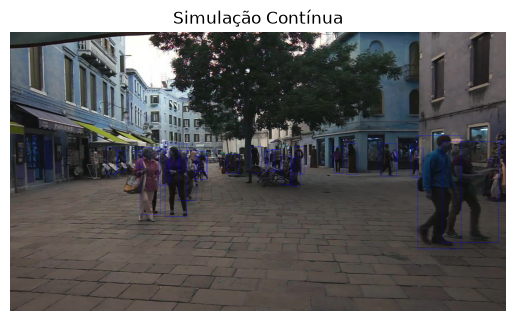

In [ ]:
frames_with_bboxes_SDP = visualize_ground_truth_RGB(frames, dets_SDP)
plot_simulation_frames(frames_with_bboxes_SDP, delay=0)

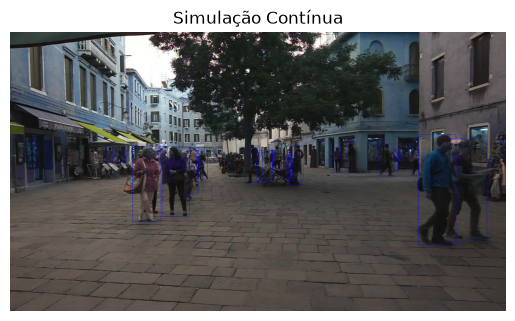

In [ ]:
frames_with_bboxes_rcnn = visualize_ground_truth_RGB(frames, dets_rcnn)
plot_simulation_frames(frames_with_bboxes_rcnn)

In [24]:
dets_SDP_naive = [
    ', '.join(box[:-1].astype(int).astype(str))+f", {box[-1].astype(str)}" 
    for box in naive_tracker_shift(ground_truth_data=dets_SDP, threshold=0.5, max_age=10)
]

dets_rcnn_naive = [
    ', '.join(box[:-1].astype(int).astype(str))+f", {box[-1].astype(str)}" 
    for box in naive_tracker_shift(ground_truth_data=dets_rcnn, threshold=0.5, max_age=10)
]

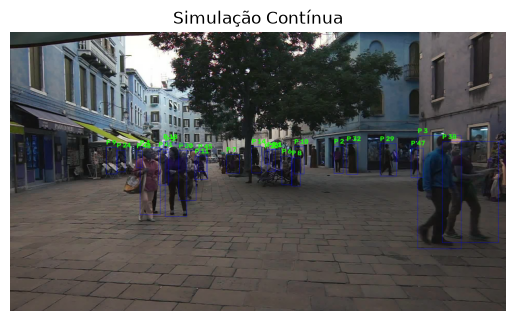

In [ ]:
frames_with_bboxes_SDP_naive = visualize_ground_truth_RGB(frames, dets_SDP_naive, put_id=True, fmt=lambda id: f"P {id}")
plot_simulation_frames(frames_with_bboxes_SDP_naive)

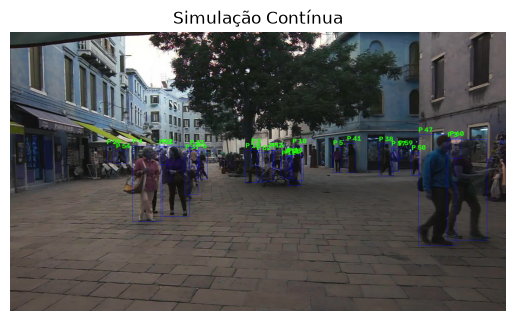

In [ ]:
frames_with_bboxes_rcnn_naive = visualize_ground_truth_RGB(frames, dets_rcnn_naive, put_id=True, fmt=lambda id: f"P {id}")
plot_simulation_frames(frames_with_bboxes_rcnn_naive)

In [25]:
metrics_1_3 = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_SDP_naive, threshold=0.5)
metrics_1_3

{'IDF1 Score': 0.6050113895216401,
 'ID Switches': 29,
 'Fragmentacoes': 51,
 'Erro de Contagem de IDs': 35,
 'Track History': {np.float64(2.0): [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1],
  np.float64(3.0): [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1],
  np.float64(8.0): [1,
   1,
   1,
   1,
   0,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   0,
   0,
   0,

In [26]:
metrics_1_3 = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_rcnn_naive, threshold=0.5)
metrics_1_3

{'IDF1 Score': 0.42122719734660036,
 'ID Switches': 36,
 'Fragmentacoes': 32,
 'Erro de Contagem de IDs': 55,
 'Track History': {np.float64(2.0): [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1],
  np.float64(3.0): [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1],
  np.float64(8.0): [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1

### 4. Regras de Associação e Gestão de Trajetórias (Rastreador Ingênuo)

**1. Regra de Associação (Matching)**
A associação temporal entre objetos recorre à sobreposição espacial e a uma estratégia de otimização local, baseada nas seguintes regras:

* **Métrica de Custo:** Utiliza-se a **Interseção sobre a União (IoU)** entre as caixas delimitadoras (*bounding boxes*) das trajetórias ativas na memória e as novas detecções do quadro atual (\(t\)).
* **Estratégia de Resolução:** Aplica-se o algoritmo de **Matching Guloso (*Greedy Match*)**. O algoritmo procura iterativamente na matriz de IoU o valor global máximo, associando esse par (memória \(\leftrightarrow\) detecção). Após o pareamento, a respectiva linha e coluna são invalidadas, e o processo repete-se para os restantes candidatos até esgotar as opções.
* **Limiar Fixo (Corte):** Para evitar associações espúrias entre objetos distantes ou sobrepostos acidentalmente, a correspondência só é validada se o valor de IoU do par guloso for maior ou igual a um limiar fixo pré-definido (por padrão, $0.5$). Pareamentos abaixo deste valor são rejeitados.

**2. Gestão de Nascimento de Tracks**
Uma trajetória é considerada nova (nascimento) sempre que uma detecção no quadro \(t\) não consegue ser associada a nenhuma identidade pré-existente. Isto ocorre em duas situações:

* Não há sobreposição geométrica suficiente com nenhuma trajetória ativa (IoU inferior ao limiar).
* Todas as trajetórias ativas na vizinhança já foram "consumidas" pelo algoritmo guloso por possuírem maior IoU com outras detecções.

Quando o nascimento ocorre, o sistema atribui um **Identificador (ID) sequencial inédito** à detecção, inicializa o seu contador de idade (quadros sem observação) a $0$ e adiciona-a ao registro de memórias ativas.

**3. Gestão de Morte de Tracks (Memória e Tolerância)**
O rastreador não descarta imediatamente um objeto que deixe de ser detectado (por exemplo, devido a uma oclusão momentânea ou falha temporal do detector R-CNN). Existe um mecanismo de tolerância regulado pelo parâmetro \(K\) (`max_age`):

* **Envelhecimento:** Se uma trajetória presente na memória não for associada a nenhuma detecção no quadro \(t\), a sua última caixa delimitadora conhecida fica temporalmente **congelada** na mesma posição espacial, e o seu contador de idade é incrementado em \(+1\).
* **Rejuvenescimento:** Se em quadros seguintes o objeto voltar a ser detectado e o IoU com a caixa "fantasma" congelada for superior ao limiar, a associação é restabelecida. A posição espacial é atualizada com a nova detecção e a idade retorna a $0$.
* **Morte Definitiva:** Se uma trajetória acumular um número de quadros consecutivos sem observação igual ou superior ao limite de tolerância (\(K\)), o objeto é declarado **morto** e a trajetória é eliminada permanentemente da memória. Um reaparecimento futuro do mesmo objeto resultará num novo nascimento e, consequentemente, numa troca de identidade explícita (*ID Switch*).

In [27]:
def det_to_str(dets):
    return [
        ", ".join([
            *d[:-1].astype(int).astype(str),
            str(d[-1])
        ])
        for d in dets
    ]

In [28]:
def avaliar_todas_sequencias(dicionario_dados_brutos, limiares_map=np.arange(0.5, 0.96, 0.05)):
    """
    Processa todas as sequencias, roda o rastreador e extrai IDF1 e mAP reais.
    dicionario_dados_brutos = {'MOT17-04': {'gt': [...], 'preds': [...]}, ...}
    """
    resultados = {}
    
    for seq_name, dados in dicionario_dados_brutos.items():
        ground_truth = dados['gt']
        predicoes = dados['preds']
        
        # Metricas Temporais (O codigo que montamos anteriormente)
        traj_metrics = evaluate_trajectories(ground_truth, predicoes, threshold=0.5)
        
        # Calculo do mAP
        parts_t = np.array([list(map(float, x.split(','))) for x in ground_truth])
        parts_p = np.array([list(map(float, x.split(','))) for x in predicoes])
        
        num_frames = int(max(np.max(parts_t[:, 0]) if len(parts_t) > 0 else 0, 
                             np.max(parts_p[:, 0]) if len(parts_p) > 0 else 0))
        
        tp_total = {limiar: 0 for limiar in limiares_map}
        fp_total = {limiar: 0 for limiar in limiares_map}
        fn_total = {limiar: 0 for limiar in limiares_map}
        
        # Processamento Frame a Frame para Detecao (mAP)
        for f in range(1, num_frames + 1):
            frame_t = parts_t[parts_t[:, 0] == f]
            frame_p = parts_p[parts_p[:, 0] == f]
            
            if len(frame_t) == 0 and len(frame_p) == 0:
                continue
                
            iou_matrix = calculate_iou_matrix(frame_p, frame_t) if len(frame_p) > 0 and len(frame_t) > 0 else np.zeros((len(frame_p), len(frame_t)))
            
            # Avalia para cada limiar do mAP (0.50 a 0.95)
            for limiar in limiares_map:
                matches_iou, _ = greedy_match(iou_matrix, len(frame_p), len(frame_t))
                tp = (matches_iou >= limiar).sum()
                tp_total[limiar] += tp
                fp_total[limiar] += len(frame_p) - tp
                fn_total[limiar] += len(frame_t) - tp
                
        # Calcula a Average Precision (AP) para cada limiar e extrai a media (mAP)
        ap_por_limiar = []
        for limiar in limiares_map:
            tp = tp_total[limiar]
            fp = fp_total[limiar]
            fn = fn_total[limiar]
            ap = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
            ap_por_limiar.append(ap)
            
        map_final = np.mean(ap_por_limiar)
        
        # Densidade (Eixo de dificuldade)
        densidade_media = len(parts_t) / num_frames if num_frames > 0 else 0
        
        # Consolida os dados da sequencia
        num_trues = len(np.unique(parts_t[:, 1])) if len(parts_t) > 0 else 1
        num_preds = len(np.unique(parts_p[:, 1])) if len(parts_p) > 0 else 0
        
        resultados[seq_name] = {
            'mAP': map_final,
            'IDF1': traj_metrics['IDF1 Score'],
            'num_preds': num_preds,
            'num_trues': num_trues,
            'id_switches': traj_metrics['ID Switches'],
            'densidade': densidade_media
        }
        
    return resultados


def plotar_descolamento(resultados_sequencias, model: str):
    # Ordenacao estrita pelo eixo de dificuldade (Densidade)
    sequencias_ordenadas = sorted(resultados_sequencias.items(), key=lambda x: x[1]['densidade'])
    
    nomes_seqs = [seq[0] for seq in sequencias_ordenadas]
    map_vals = [seq[1]['mAP'] for seq in sequencias_ordenadas]
    idf1_vals = [seq[1]['IDF1'] for seq in sequencias_ordenadas]
    
    # Razoes para quantificar o fracasso
    razao_ids = [seq[1]['num_preds'] / seq[1]['num_trues'] for seq in sequencias_ordenadas]
    switches_por_id_real = [seq[1]['id_switches'] / seq[1]['num_trues'] for seq in sequencias_ordenadas]

    # Estrutura de duplo painel
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(f'{model} - Quantificação do Fracasso: O Descolamento do Rastreador Ingénuo', fontsize=14, fontweight='bold')

    # Painel 1: mAP vs IDF1
    ax1.plot(nomes_seqs, map_vals, marker='o', color='royalblue', linewidth=2, label='mAP (Deteção)')
    ax1.plot(nomes_seqs, idf1_vals, marker='s', color='darkorange', linewidth=2, label='IDF1 (Trajetória)')
    ax1.set_ylabel('Pontuação', fontsize=11)
    ax1.set_title('Desempenho Geral (Deteção vs Associação)', fontsize=12)
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='lower left')

    # Painel 2: Explosao de IDs e Switches
    ax2.plot(nomes_seqs, razao_ids, marker='^', color='firebrick', linewidth=2, label='IDs Previstos / IDs Verdadeiros')
    ax2.plot(nomes_seqs, switches_por_id_real, marker='D', color='purple', linewidth=2, label='ID Switches / ID Verdadeiro')
    ax2.axhline(y=1.0, color='gray', linestyle=':', label='Razão Ideal (1.0 = Sem Fragmentação/Switches)')
    ax2.set_xlabel('Sequências de Vídeo (Dificuldade Crescente → Pessoas por Quadro)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Taxa / Multiplicador', fontsize=11)
    ax2.set_title('Descolamento da Identidade', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

In [29]:
# Estrutura os dados para a funcao
eval_SDP = {
    name: {
        "gt": ground_truth_SDP_by_video[name], 
        "preds": det_to_str(naive_tracker_shift(ground_truth_data=dets_SDP_by_video[name], threshold=0.5, max_age=10))
    }
    for name in ground_truth_SDP_by_video.keys()
}

eval_rcnn = {
    name: {
        "gt": ground_truth_SDP_by_video[name], 
        "preds": det_to_str(naive_tracker_shift(ground_truth_data=dets_rcnn_by_video[name], threshold=0.5, max_age=10))
    }
    for name in ground_truth_SDP_by_video.keys()
}

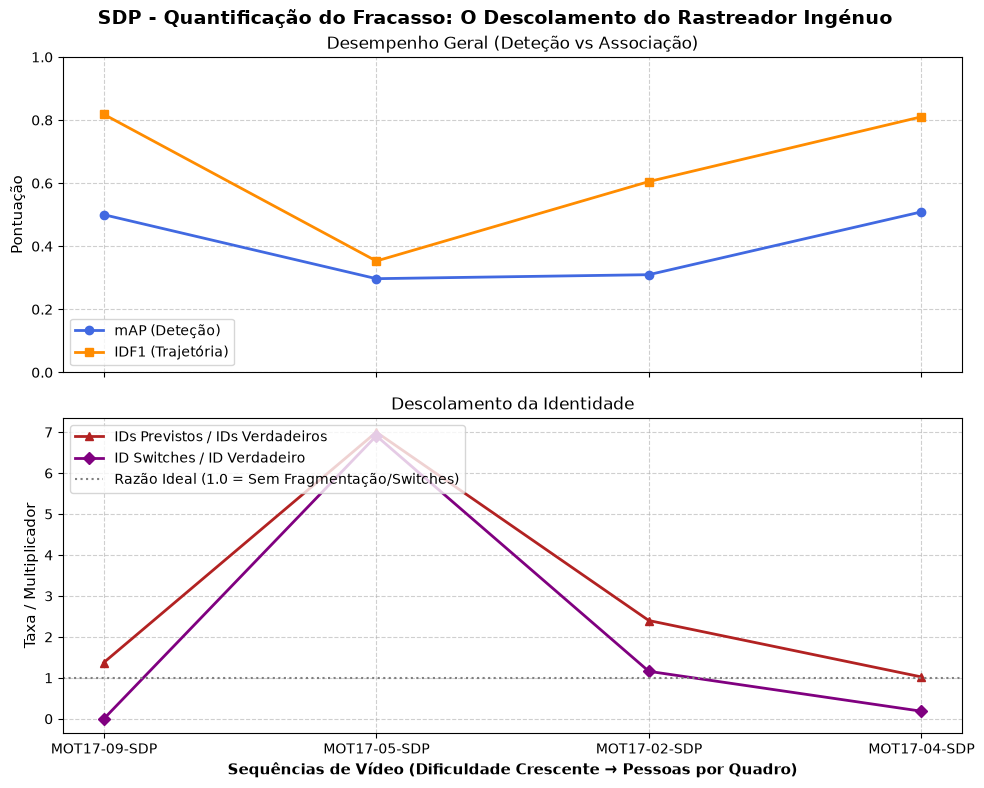

In [30]:
resultados_SDP = avaliar_todas_sequencias(eval_SDP)
plotar_descolamento(resultados_SDP, model="SDP")

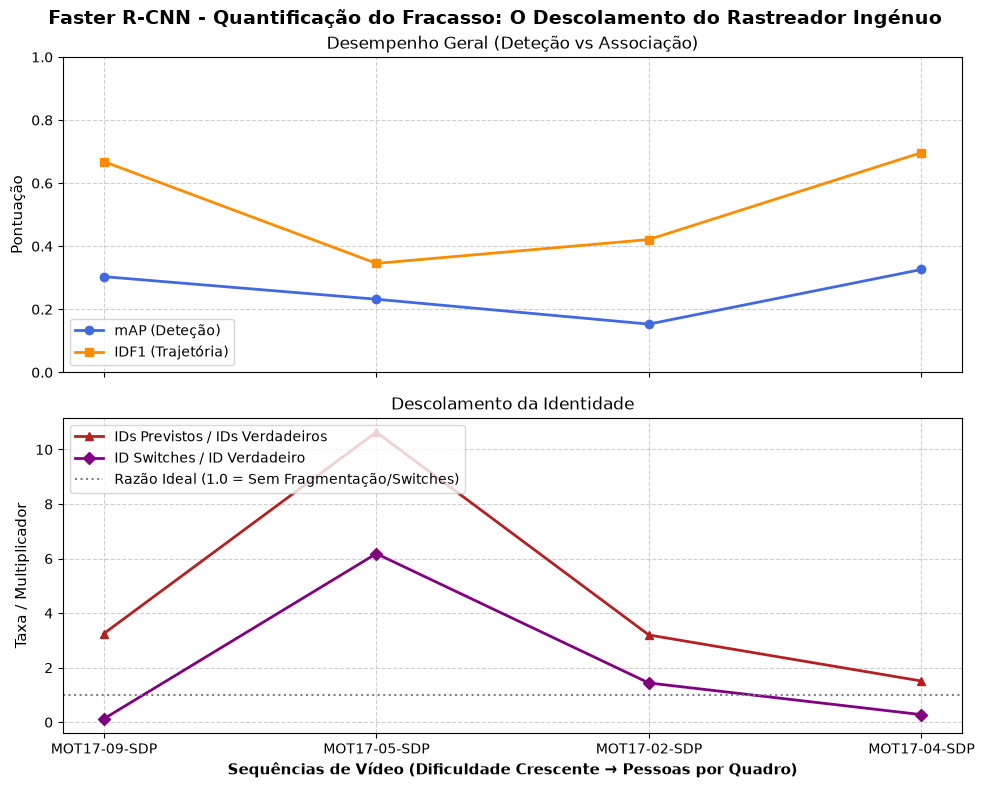

In [31]:
resultados_rcnn = avaliar_todas_sequencias(eval_rcnn)
plotar_descolamento(resultados_rcnn, model="Faster R-CNN")

---

# Parte 2

In [32]:
TREINO   = ['MOT17-04-SDP', 'MOT17-05-SDP', 'MOT17-09-SDP', 'MOT17-10-SDP']   # 2 paradas + 2 móveis
VAL_SEQ  = ['MOT17-11-SDP', 'MOT17-13-SDP']     # escolha de threshold / max_age / época
TEST_SEQ = 'MOT17-02-SDP'                       # nunca usada em treino nem em ajuste

gt_by_seq   = gt_strings_por_sequencia(train_dataset)
dets_by_seq = dets_strings_por_sequencia(train_dataset)      # det.txt do SDP (fonte padrão)
tamanhos    = tamanhos_sequencias(train_dataset, TREINO + VAL_SEQ + [TEST_SEQ])

T = 16
J_treino = janelas_das_sequencias(gt_by_seq, tamanhos, TREINO,  T=T)
J_val    = janelas_das_sequencias(gt_by_seq, tamanhos, VAL_SEQ, T=T)
print(J_treino.shape, J_val.shape)

(8863, 17, 4) (2503, 17, 4)


In [33]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
modelo_gru = BBoxTrackerGRU(hidden_size=64)
modelo_gru, hist = treinar_gru(modelo_gru, J_treino, J_val, epochs=30, lr=2e-3,
                               modo='teacher', clip=1.0, device=device)
salvar_checkpoint(modelo_gru, 'checkpoints/gru_teacher.pt', extra={'T': T})


[teacher] época 000 | treino 0.02745 | val 0.02348 (vel. zero: 0.06487)
[teacher] época 005 | treino 0.01866 | val 0.01910 (vel. zero: 0.06487)
[teacher] época 010 | treino 0.01815 | val 0.02218 (vel. zero: 0.06487)
[teacher] época 015 | treino 0.01777 | val 0.01889 (vel. zero: 0.06487)
[teacher] época 020 | treino 0.01744 | val 0.01963 (vel. zero: 0.06487)
[teacher] época 025 | treino 0.01675 | val 0.02021 (vel. zero: 0.06487)
[teacher] época 029 | treino 0.01642 | val 0.01963 (vel. zero: 0.06487)


In [34]:
import itertools
def idf1_val(thr, ma):
    xs = []
    for s in VAL_SEQ:
        w, h = tamanhos[s]
        t, _ = comparar_trackers(dets_by_seq[s], gt_by_seq[s], {'GRU': MovimentoGRU(modelo_gru, 'cpu', w, h)},
                                 thr, ma, incluir_naive=False)
        xs.append(t['GRU']['IDF1 Score'])
    return np.mean(xs)
grid = {(thr, ma): idf1_val(thr, ma) for thr, ma in itertools.product([0.2, 0.3, 0.5], [3, 10, 30])}
THR, MAX_AGE = max(grid, key=grid.get); print(THR, MAX_AGE)

for seq in VAL_SEQ + [TEST_SEQ]:
    w, h = tamanhos[seq]
    movs = {'Vel. zero': MovimentoZero(), 'Kalman CV': MovimentoKalman(),
            'GRU': MovimentoGRU(modelo_gru, 'cpu', w, h)}
    tab, _ = comparar_trackers(dets_by_seq[seq], gt_by_seq[seq], movs, THR, MAX_AGE)
    imprimir_tabela(tab, f"== {seq} ==")


0.2 3
== MOT17-11-SDP ==
modelo            IDF1  switches  fragm.  |Δ IDs|
Naive (P1)      0.5693       176     257      149
Vel. zero       0.5707       113     130       83
Kalman CV       0.5694       127     136       86
GRU             0.5706       128     138      101
== MOT17-13-SDP ==
modelo            IDF1  switches  fragm.  |Δ IDs|
Naive (P1)      0.4382       667     393      536
Vel. zero       0.4393       509     376      305
Kalman CV       0.5647       223     277      137
GRU             0.5124       275     310      171
== MOT17-02-SDP ==
modelo            IDF1  switches  fragm.  |Δ IDs|
Naive (P1)      0.3289       460    1096      538
Vel. zero       0.3305       308     670      283
Kalman CV       0.3392       306     695      306
GRU             0.3224       401     733      330


Na fronteira entre janelas quebram: (i) o estado recorrente de cada track (reinicia em zero), (ii) a numeração dos IDs (cada janela cria IDs próprios) e (iii) tracks ocluídas na fronteira. Como a representação é pequena por track (h, última caixa, delta, idade e ID), dá para (a) carregar esse estado de uma janela para a seguinte (o truncamento vale só para o backprop, não para a inferência), ou (b) sobrepor janelas por K quadros e casar as tracks nos quadros comuns por IoU (Hungarian), renomeando os IDs da janela nova.

---

# Parte 3

In [56]:
import torch.nn as nn
import torch.optim as optim

class BBoxTrackerRNN(nn.Module):
    def __init__(self, rnn_type='GRU', input_size=4, hidden_size=64):
        super().__init__()
        self.rnn_type = rnn_type
        if rnn_type == 'RNN':
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
            
        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self, x, hidden=None):
        out, hidden = self.rnn(x, hidden)
        return self.fc(out[:, -1, :]), hidden

def treinar_modelo(modelo, ground_truth_limpo, device, epochs=50, T=8):
    dets = np.array([list(map(float, x.split(','))) for x in ground_truth_limpo])
    ids_unicos = np.unique(dets[:, 1])
    
    X_train, Y_train = [], []
    for uid in ids_unicos:
        traj = dets[dets[:, 1] == uid]
        if len(traj) <= T: continue
        
        coords = traj[:, 2:6].copy()
        # Normalização
        coords[:, 0] /= 1920.0
        coords[:, 1] /= 1080.0
        coords[:, 2] /= 1920.0
        coords[:, 3] /= 1080.0
        
        # BPTT Truncado: Sequência de tamanho exato T, para prever T+1
        for i in range(len(coords) - T):
            X_train.append(coords[i:i+T]) 
            Y_train.append(coords[i+T])   
            
    if not X_train: return modelo
    
    X_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
    Y_tensor = torch.tensor(np.array(Y_train), dtype=torch.float32)
    
    # Reduzido ligeiramente para garantir estabilidade com o embaralhamento
    optimizer = optim.Adam(modelo.parameters(), lr=0.005) 
    criterion = nn.SmoothL1Loss()
    
    num_amostras = X_tensor.size(0)
    tamanho_batch = 128
    
    melhor_loss = float('inf')
    melhores_pesos = None
    
    for epoch in range(epochs):
        modelo.train()
        
        # Embaralha os dados para evitar que a rede decore as últimas trajetórias
        indices = torch.randperm(num_amostras)
        erro_acumulado = 0.0
        lotes = 0
        
        for i in range(0, num_amostras, tamanho_batch):
            idx_batch = indices[i:i+tamanho_batch]
            
            x_batch = X_tensor[idx_batch].to(device)
            y_batch = Y_tensor[idx_batch].to(device)
            
            optimizer.zero_grad()
            pred, _ = modelo(x_batch) 
            loss = criterion(pred, y_batch)
            loss.backward()
            
            # Impede que o erro de uma caixa ruim exploda a rede (Gradient Clipping)
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            optimizer.step()
            
            erro_acumulado += loss.item()
            lotes += 1
            
        loss_media = erro_acumulado / max(1, lotes)
        
        # Retém o melhor modelo da ablação
        if loss_media < melhor_loss:
            melhor_loss = loss_media
            melhores_pesos = copy.deepcopy(modelo.state_dict())
            
    # Restaura o campeão antes de devolver para o teste do IDF1
    if melhores_pesos is not None:
        modelo.load_state_dict(melhores_pesos)
        
    return modelo


def gru_tracker_shift(ground_truth_data, model, device, img_w, img_h, threshold=0.3, max_age=3, min_hits=2, T=8):
    detections = np.array([list(map(float, x.split(','))) for x in ground_truth_data])
    if len(detections) == 0: return []
    num_frames = int(detections[-1, 0])
    
    tracked_results = []
    next_new_id = 1 
    active_tracks = {}
    model.eval()
    
    for f in range(1, num_frames + 1):
        frame_t = detections[detections[:, 0] == f]
        active_ids = list(active_tracks.keys())
        predicted_matrix = []
        
        # --- PASSO 1: PREVISÃO ONLINE (Estado mantido) ---
        for tid in active_ids:
            track = active_tracks[tid]
            
            # Pega APENAS a última observação (Passo t-1)
            last_obs = track['history'][-1]
            seq_input = torch.tensor([last_obs], dtype=torch.float32).unsqueeze(0).to(device)
            
            # Passa o estado oculto anterior para manter a memória (True RNN)
            with torch.no_grad():
                pred_norm, new_hidden = model(seq_input, track['hidden'])
                
            track['next_hidden'] = new_hidden # Guarda para atualizar se a track sobreviver
            
            pred_box = pred_norm.view(-1).cpu().numpy()
            x = pred_box[0] * img_w
            y = pred_box[1] * img_h
            w = track['bbox'][4] # Mantém escala
            h = track['bbox'][5]
            
            dummy_box = np.zeros(9)
            dummy_box[0:2] = [f, tid]
            dummy_box[2:6] = [x, y, w, h]
            dummy_box[6:9] = 1.0
            predicted_matrix.append(dummy_box)
             
        predicted_matrix = np.array(predicted_matrix) if len(predicted_matrix) > 0 else np.zeros((0, 9))
        
        # --- PASSO 2: MATCHING ---
        if len(predicted_matrix) > 0 and len(frame_t) > 0:
            iou_matrix = calculate_iou_matrix(predicted_matrix, frame_t)
            matches_iou, matches = greedy_match(iou_matrix, len(predicted_matrix), len(frame_t))
        else:
            matches_iou, matches = [0]*len(predicted_matrix), [None]*len(predicted_matrix)
            
        matched_current_to_memory = {}
        matched_memory_indices = set()
        
        for p_idx in range(len(predicted_matrix)):
            t_idx = matches[p_idx]
            if t_idx is not None and matches_iou[p_idx] >= threshold:
                matched_current_to_memory[int(t_idx)] = p_idx
                matched_memory_indices.add(p_idx)
                
        # --- PASSO 3: ATUALIZAÇÃO ---
        for t_idx in range(len(frame_t)):
            res = frame_t[t_idx].copy()
            norm_obs = [res[2]/img_w, res[3]/img_h, res[4]/img_w, res[5]/img_h]
            
            if t_idx in matched_current_to_memory:
                p_idx = matched_current_to_memory[t_idx]
                track_id = active_ids[p_idx]
                
                res[1] = track_id
                active_tracks[track_id]['bbox'] = res
                active_tracks[track_id]['history'].append(norm_obs)
                active_tracks[track_id]['hidden'] = active_tracks[track_id]['next_hidden'] # Atualiza Memória
                active_tracks[track_id]['age'] = 0
                active_tracks[track_id]['hits'] += 1
            else:
                track_id = next_new_id
                next_new_id += 1
                res[1] = track_id
                
                active_tracks[track_id] = {
                    'bbox': res, 'age': 0, 'history': [norm_obs], 'hits': 1,
                    'hidden': None # Nasce com memória vazia
                }
                
            if active_tracks[res[1]]['hits'] >= min_hits:
                tracked_results.append(res)
            
        # --- PASSO 4: OCLUSÃO E MORTE (A RNN Roda no Escuro) ---
        tracks_to_delete = []
        for p_idx, track_id in enumerate(active_ids):
            if p_idx not in matched_memory_indices:
                active_tracks[track_id]['age'] += 1
                
                if active_tracks[track_id]['age'] < max_age:
                    fake_res = predicted_matrix[p_idx].copy()
                    active_tracks[track_id]['bbox'] = fake_res
                    
                    # Oclusão: A previsão da rede torna-se a nova observação
                    norm_fake = [fake_res[2]/img_w, fake_res[3]/img_h, fake_res[4]/img_w, fake_res[5]/img_h]
                    active_tracks[track_id]['history'].append(norm_fake)
                    active_tracks[track_id]['hidden'] = active_tracks[track_id]['next_hidden'] # Memória avança
                    
                    if active_tracks[track_id]['hits'] >= min_hits:
                        tracked_results.append(fake_res)
                else:
                    tracks_to_delete.append(track_id)
                    
        for tid in tracks_to_delete:
            del active_tracks[tid]

    return np.array(tracked_results)

def rodar_ablacao_eixo1(ground_truth_limpo, device, img_w=1920, img_h=1080):
    seeds = [23, 42, 24]
    modelos = ['RNN', 'LSTM', 'GRU']
    resultados = {}
    
    melhor_idf1_geral = -1.0
    caminho_melhor_modelo = "checkpoints/melhor_modelo_eixo1.pth"
    
    for rnn_type in modelos:
        print(f"\n--- Treinando e Testando: {rnn_type} ---")
        idf1_scores = []
        
        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)
            
            # CORREÇÃO: Usa 'rnn_type' igual à classe do seu notebook
            model = BBoxTrackerRNN(rnn_type=rnn_type, input_size=4, hidden_size=64).to(device)
            model = treinar_modelo(model, ground_truth_limpo, device, epochs=50, T=8)

            tracks_geradas = gru_tracker_shift(ground_truth_limpo, model, device, img_w, img_h, threshold=0.3, max_age=3, min_hits=2, T=8)
            tracks_geradas = det_to_str(tracks_geradas)
            
            if len(tracks_geradas) > 0:
                traj_metrics = evaluate_trajectories(ground_truth_limpo, tracks_geradas, threshold=0.5)
                idf1_atual = traj_metrics['IDF1 Score']
            else:
                idf1_atual = 0.0
                
            idf1_scores.append(idf1_atual)
            print(f"Seed {seed}: IDF1 = {idf1_atual:.4f}")
            
            # CORREÇÃO: Exporta de forma totalmente segura e nativa
            if idf1_atual > melhor_idf1_geral:
                melhor_idf1_geral = idf1_atual
                torch.save({
                    'state_dict': model.state_dict(),
                    'rnn_type': rnn_type,
                    'idf1': idf1_atual
                }, caminho_melhor_modelo)
                print(f"[*] Novo melhor modelo ({rnn_type}) exportado para {caminho_melhor_modelo}")
                
        resultados[rnn_type] = {
            'IDF1_mean': np.mean(idf1_scores),
            'IDF1_std': np.std(idf1_scores)
        }
        
    return resultados, caminho_melhor_modelo

In [57]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LARGURA_VIDEO = 1920
ALTURA_VIDEO = 1080

# Executar a ablacao do Eixo 1 e capturar o caminho do modelo salvo
resultados_finais_eixo1, caminho_campeao = rodar_ablacao_eixo1(
    ground_truth_limpo=ground_truth_SDP, 
    device=device, 
    img_w=LARGURA_VIDEO, 
    img_h=ALTURA_VIDEO
)

print("\n" + "="*50)
print("RESULTADOS FINAIS - EIXO 1 (Média ± Desvio Padrão)")
print("="*50)
for modelo, res in resultados_finais_eixo1.items():
    print(f"Modelo {modelo:5s} | IDF1: {res['IDF1_mean']:.4f} ± {res['IDF1_std']:.4f}")
print(f"\nMelhor modelo exportado para: {caminho_campeao}")


--- Treinando e Testando: RNN ---
Seed 23: IDF1 = 0.0404
[*] Novo melhor modelo (RNN) exportado para checkpoints/melhor_modelo_eixo1.pth
Seed 42: IDF1 = 0.1966
[*] Novo melhor modelo (RNN) exportado para checkpoints/melhor_modelo_eixo1.pth
Seed 24: IDF1 = 0.0133

--- Treinando e Testando: LSTM ---
Seed 23: IDF1 = 0.0259
Seed 42: IDF1 = 0.0198
Seed 24: IDF1 = 0.0168

--- Treinando e Testando: GRU ---
Seed 23: IDF1 = 0.0784
Seed 42: IDF1 = 0.1016
Seed 24: IDF1 = 0.0843

RESULTADOS FINAIS - EIXO 1 (Média ± Desvio Padrão)
Modelo RNN   | IDF1: 0.0834 ± 0.0808
Modelo LSTM  | IDF1: 0.0209 ± 0.0038
Modelo GRU   | IDF1: 0.0881 ± 0.0099

Melhor modelo exportado para: checkpoints/melhor_modelo_eixo1.pth


In [59]:
def rodar_ablacao_comprimento_janela(ground_truth_limpo, device, img_w=1920, img_h=1080):
    seeds = [23, 42, 24]
    modelos = ['RNN', 'LSTM', 'GRU']
    janelas_T = [4, 8, 16, 32]
    
    resultados_T = {modelo: [] for modelo in modelos}
    
    # --- MODIFICAÇÃO: Variáveis para reter o modelo campeão ---
    melhor_idf1_geral = -1.0
    caminho_melhor_modelo = "checkpoints/melhor_modelo_janela.pth"
    
    for modelo in modelos:
        print(f"\n" + "="*40)
        print(f"Testando a quebra do modelo: {modelo}")
        print("="*40)
        
        for T in janelas_T:
            idf1_scores = []
            for seed in seeds:
                torch.manual_seed(seed)
                np.random.seed(seed)
                
                net = BBoxTrackerRNN(rnn_type=modelo, input_size=4, hidden_size=64).to(device)
                
                # Treina com o T especifico
                net = treinar_modelo(net, ground_truth_limpo, device, epochs=50, T=T)
                
                # Testa com o T especifico
                tracks = gru_tracker_shift(
                    ground_truth_limpo, net, device, img_w, img_h, 
                    threshold=0.3, max_age=3, min_hits=2, T=T
                )
                tracks = det_to_str(tracks)
                
                if len(tracks) > 0:
                    metrica = evaluate_trajectories(ground_truth_limpo, tracks, threshold=0.5)
                    idf1_atual = metrica['IDF1 Score']
                else:
                    idf1_atual = 0.0
                    
                idf1_scores.append(idf1_atual)
                
                # --- MODIFICAÇÃO: Exporta de forma totalmente segura e nativa ---
                if idf1_atual > melhor_idf1_geral:
                    melhor_idf1_geral = idf1_atual
                    torch.save({
                        'state_dict': net.state_dict(),
                        'rnn_type': modelo,
                        'T': T,
                        'idf1': idf1_atual
                    }, caminho_melhor_modelo)
                    print(f"[*] Novo melhor modelo ({modelo}, T={T}) exportado para {caminho_melhor_modelo}")
                    
            media_idf1 = np.mean(idf1_scores)
            resultados_T[modelo].append(media_idf1)
            print(f" -> Janela T={T:2d} | IDF1 Médio: {media_idf1:.4f}")
            
    # Retorna também o caminho do campeão
    return resultados_T, janelas_T, caminho_melhor_modelo

In [ ]:
res_janelas, lista_T, caminho_campeao_janelas = rodar_ablacao_comprimento_janela(ground_truth_SDP, device)


Testando a quebra do modelo: RNN
[*] Novo melhor modelo (RNN, T=4) exportado para checkpoints/melhor_modelo_janela.pth
[*] Novo melhor modelo (RNN, T=4) exportado para checkpoints/melhor_modelo_janela.pth
 -> Janela T= 4 | IDF1 Médio: 0.0348
[*] Novo melhor modelo (RNN, T=8) exportado para checkpoints/melhor_modelo_janela.pth
 -> Janela T= 8 | IDF1 Médio: 0.0834
[*] Novo melhor modelo (RNN, T=16) exportado para checkpoints/melhor_modelo_janela.pth
 -> Janela T=16 | IDF1 Médio: 0.1259
 -> Janela T=32 | IDF1 Médio: 0.0555

Testando a quebra do modelo: LSTM
 -> Janela T= 4 | IDF1 Médio: 0.0150
 -> Janela T= 8 | IDF1 Médio: 0.0209
[*] Novo melhor modelo (LSTM, T=16) exportado para checkpoints/melhor_modelo_janela.pth
 -> Janela T=16 | IDF1 Médio: 0.1350
 -> Janela T=32 | IDF1 Médio: 0.0941

Testando a quebra do modelo: GRU
 -> Janela T= 4 | IDF1 Médio: 0.0235
 -> Janela T= 8 | IDF1 Médio: 0.0881
 -> Janela T=16 | IDF1 Médio: 0.1275
 -> Janela T=32 | IDF1 Médio: 0.1281


ValueError: too many values to unpack (expected 2, got 3)

---

# Parte 4

### 1- Horizonte Analítico: A Curva do Gradiente que Desvanece

[teacher] época 000 | treino 0.02343 | val 0.01954 (vel. zero: 0.06487)
[teacher] época 005 | treino 0.01911 | val 0.01846 (vel. zero: 0.06487)
[teacher] época 010 | treino 0.01892 | val 0.01829 (vel. zero: 0.06487)
[teacher] época 015 | treino 0.01869 | val 0.01823 (vel. zero: 0.06487)
[teacher] época 020 | treino 0.01846 | val 0.01901 (vel. zero: 0.06487)
[teacher] época 025 | treino 0.01803 | val 0.01880 (vel. zero: 0.06487)
[teacher] época 029 | treino 0.01780 | val 0.01865 (vel. zero: 0.06487)


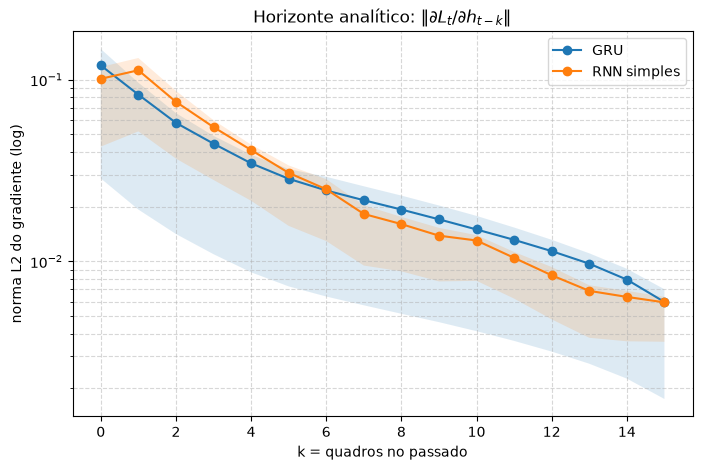

queda em 8 passos: {'GRU': 6.2, 'RNN simples': 6.3}


In [39]:
J_test = janelas_das_sequencias(gt_by_seq, tamanhos, [TEST_SEQ], T=T, passo=8)
curvas = {'GRU': curva_gradiente(modelo_gru, J_test, T=T, device=device)}

# opcional: comparar com RNN simples (treine antes com treinar_gru, mesmo orçamento de parâmetros)
import GRU as G
rnn = G.BBoxTrackerRNN('RNN', hidden_size=110)          # ajuste hidden_size para igualar nº de parâmetros
rnn, _ = treinar_gru(rnn, J_treino, J_val, epochs=30, device=device)
curvas['RNN simples'] = curva_gradiente(rnn, J_test, T=T, device=device)

plot_curvas_gradiente(curvas)
print("queda em 8 passos:", {k: round(fator_de_queda(v, 8), 1) for k, v in curvas.items()})


### 2- Horizonte Empírico: Sobrevivência à Oclusão

Lacunas (GT sem predição associada): 768 | sobreviveram (mesmo ID): 419 | falharam: 349
Sobrevivência máxima do estado: 32 quadros
Lacuna média que sobrevive: 3.0 | que causa falha: 20.1 | trocas diretas de ID: 401
oclusão no dataset: mediana 27.5 | p90 124.10000000000005 | máx 332


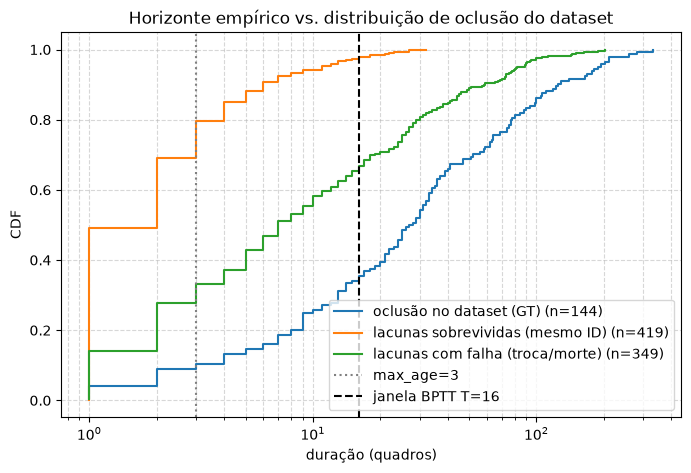

 duração      n  %sobrevive
     1-2    386       74.9%
     3-5    133       60.2%
    6-10     79       32.9%
   11-20     62       29.0%
    >=21    108        5.6%


[('1-2', 386, np.float64(0.7487046632124352)),
 ('3-5', 133, np.float64(0.6015037593984962)),
 ('6-10', 79, np.float64(0.3291139240506329)),
 ('11-20', 62, np.float64(0.2903225806451613)),
 ('>=21', 108, np.float64(0.05555555555555555))]

In [40]:
w, h = tamanhos[TEST_SEQ]
gt, dets = gt_by_seq[TEST_SEQ], dets_by_seq[TEST_SEQ]
preds_gru = tracks_to_str(rodar_tracker(dets, MovimentoGRU(modelo_gru, 'cpu', w, h), THR, MAX_AGE))

timeline, eventos, resumo = medir_horizonte(gt, preds_gru)
dur_ds = duracoes_oclusao_dataset(gt, vis_thr=0.3)
print("oclusão no dataset: mediana", np.median(dur_ds), "| p90", np.percentile(dur_ds, 90), "| máx", dur_ds.max())
plot_horizonte_empirico(dur_ds, eventos, max_age=MAX_AGE, T_treino=T)
taxa_sobrevivencia_por_duracao(eventos)


### 3- Galeria de Falhas (Recorte Visual)

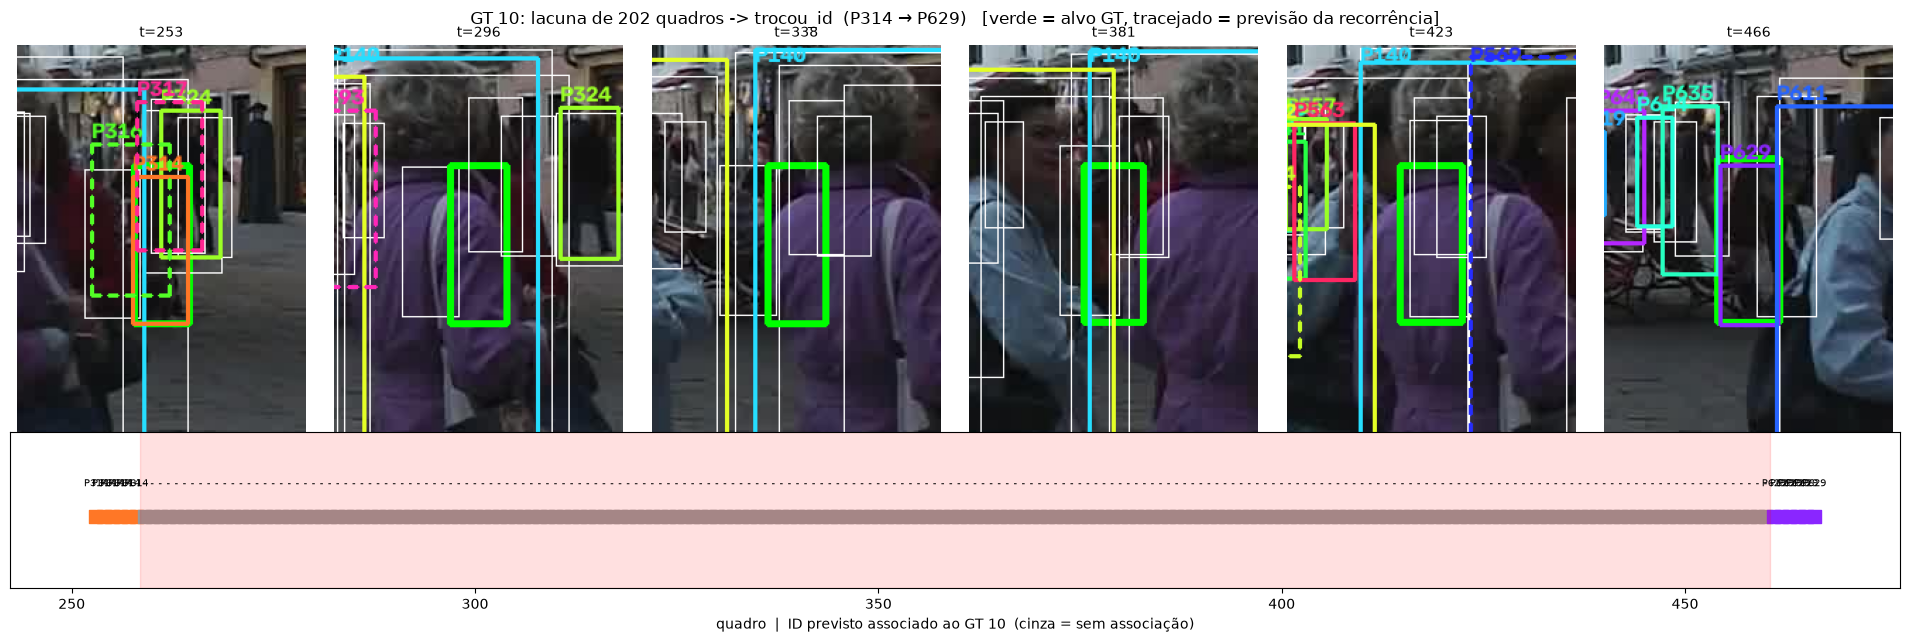

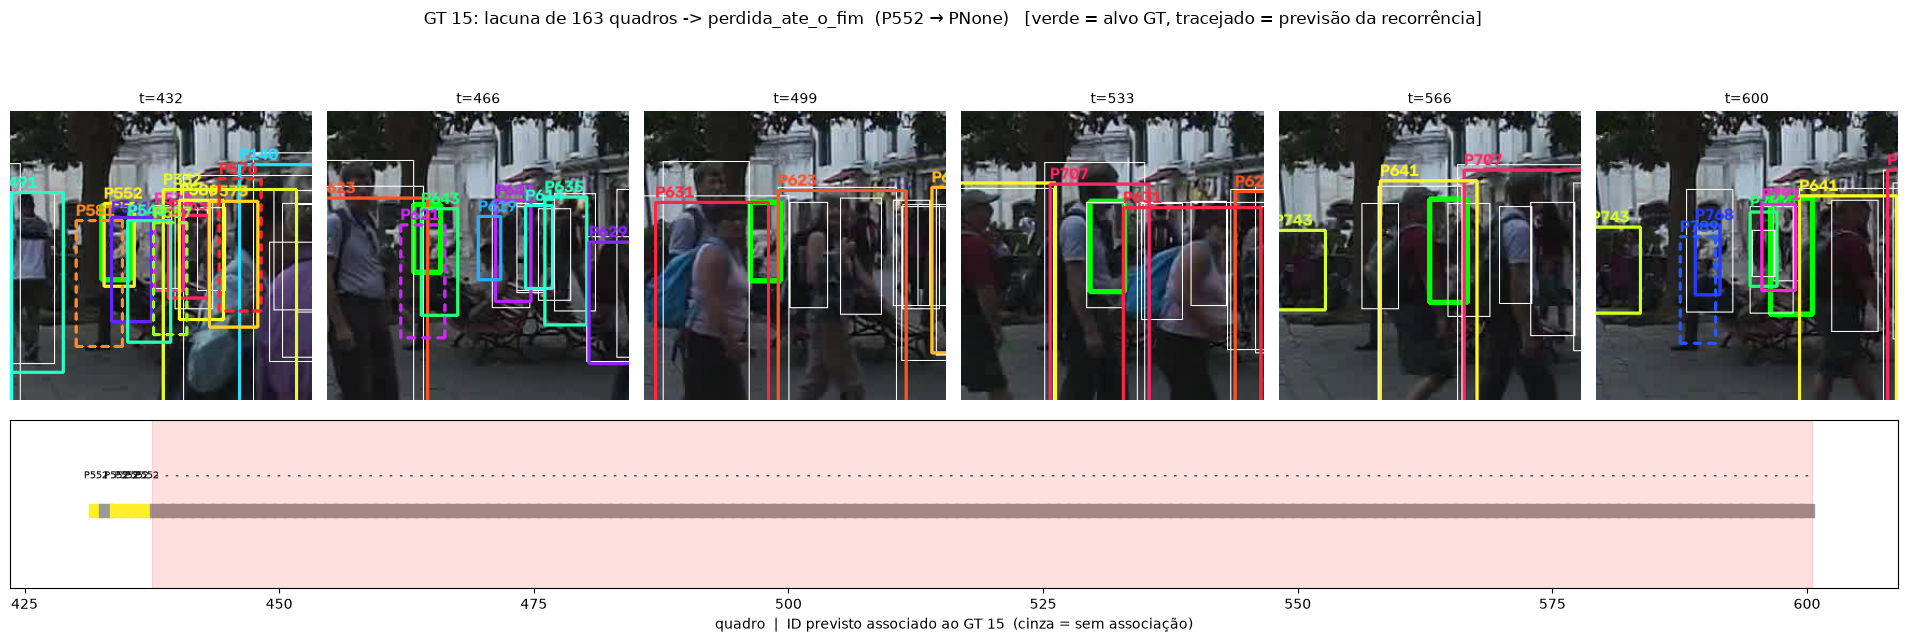

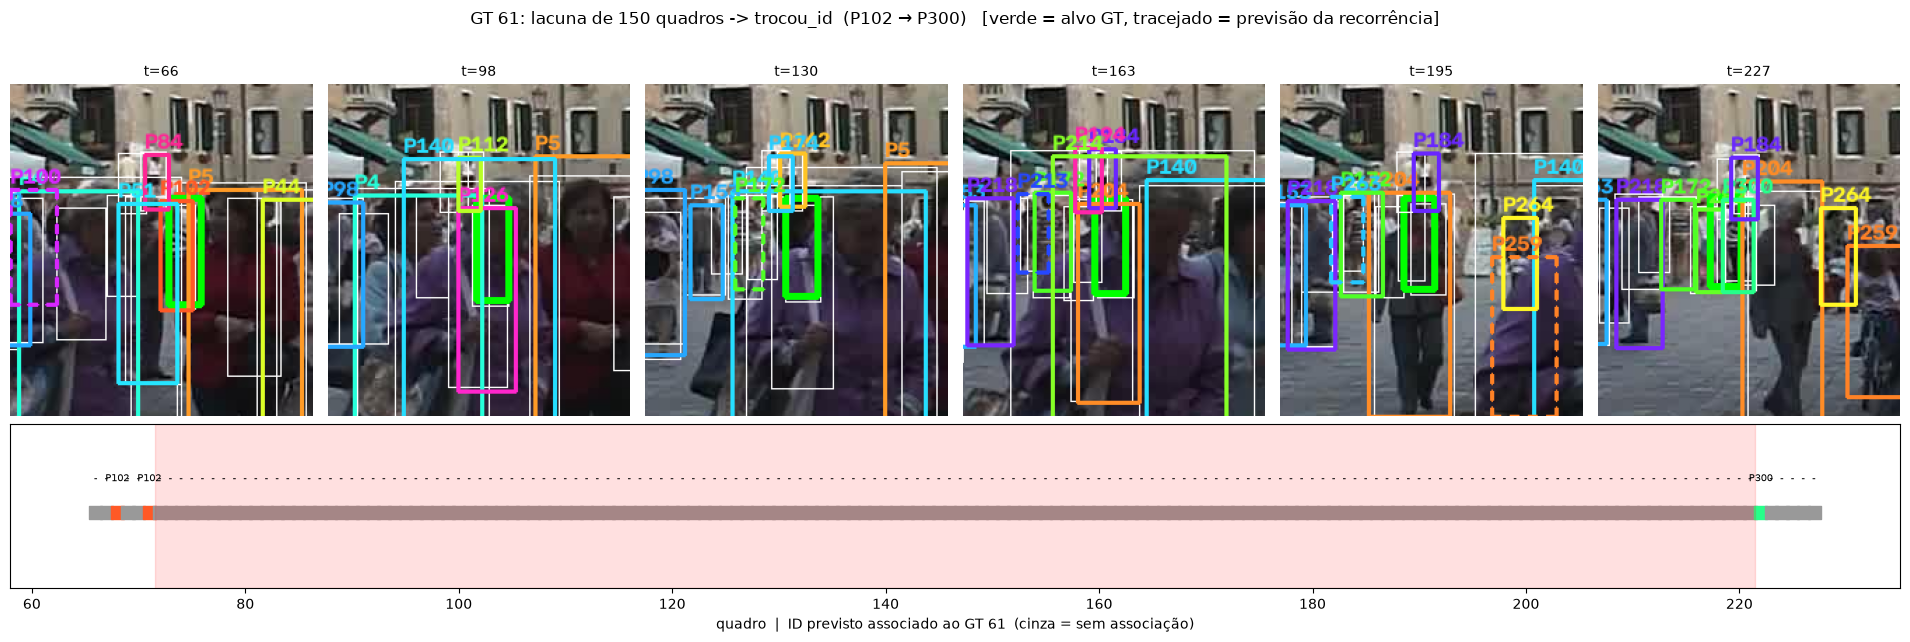

O objeto GT 10 fica 202 quadros sem observação associada (trocou_id); max_age = 3 (< duração da lacuna: a track morre antes de a oclusão acabar); minha janela de BPTT é 16 (a lacuna é maior que a janela: o treino nunca viu uma sequência tão longa sem observação); a norma do gradiente cai 6x em 8 passos.
O objeto GT 15 fica 163 quadros sem observação associada (perdida_ate_o_fim); max_age = 3 (< duração da lacuna: a track morre antes de a oclusão acabar); minha janela de BPTT é 16 (a lacuna é maior que a janela: o treino nunca viu uma sequência tão longa sem observação); a norma do gradiente cai 6x em 8 passos.
O objeto GT 61 fica 150 quadros sem observação associada (trocou_id); max_age = 3 (< duração da lacuna: a track morre antes de a oclusão acabar); minha janela de BPTT é 16 (a lacuna é maior que a janela: o treino nunca viu uma sequência tão longa sem observação); a norma do gradiente cai 6x em 8 passos.


In [41]:
get_frame = frame_loader(train_dataset, TEST_SEQ)
falhas = galeria_de_falhas(get_frame, gt, preds_gru, timeline, eventos, n=3)
for e in falhas:
    print(diagnostico_texto(e, curvas['GRU'], T_treino=T, max_age=MAX_AGE))

### 4- Correção

[rollout] época 000 | treino 0.47586 | val 0.92114 (vel. zero: 0.06388)
[rollout] época 005 | treino 0.28411 | val 0.77610 (vel. zero: 0.06388)
[rollout] época 010 | treino 0.26660 | val 0.73048 (vel. zero: 0.06388)
[rollout] época 015 | treino 0.27048 | val 0.71758 (vel. zero: 0.06388)
[rollout] época 019 | treino 0.25879 | val 0.72787 (vel. zero: 0.06388)


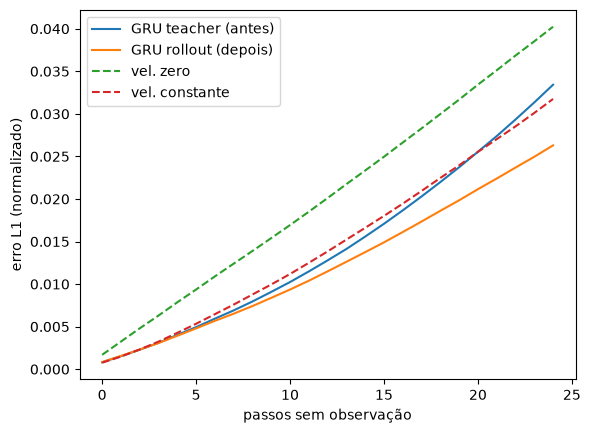

config                        IDF1  switches  fragm.  sobrev.máx  lac.falha(média)
GRU teacher (antes)         0.3224       401     733          32              20.1
GRU rollout (depois)        0.3264       380     728          32              20.2


In [42]:
J_treino32 = janelas_das_sequencias(gt_by_seq, tamanhos, TREINO,  T=32)
J_val32    = janelas_das_sequencias(gt_by_seq, tamanhos, VAL_SEQ, T=32)

modelo_roll = BBoxTrackerGRU(hidden_size=64)
modelo_roll.load_state_dict(modelo_gru.state_dict())
modelo_roll, _ = treinar_gru(modelo_roll, J_treino32, J_val32, epochs=20, lr=1e-3,
                             modo='rollout', warm=8, clip=1.0, device=device)
salvar_checkpoint(modelo_roll, 'checkpoints/gru_rollout.pt', extra={'T': 32, 'warm': 8})

# erro por horizonte (free-running) antes x depois x baselines
g0, z0, c0 = erro_por_horizonte(modelo_gru,  J_val32, warm=8, device=device)
g1, _,  _  = erro_por_horizonte(modelo_roll, J_val32, warm=8, device=device)
plt.plot(g0, label='GRU teacher (antes)'); plt.plot(g1, label='GRU rollout (depois)')
plt.plot(z0, '--', label='vel. zero'); plt.plot(c0, '--', label='vel. constante')
plt.xlabel('passos sem observação'); plt.ylabel('erro L1 (normalizado)'); plt.legend(); plt.show()

# antes/depois no rastreamento (mesma associação, mesmos limiares)
linhas = {}
for nome, mod in {'GRU teacher (antes)': modelo_gru, 'GRU rollout (depois)': modelo_roll}.items():
    p = tracks_to_str(rodar_tracker(dets, MovimentoGRU(mod, 'cpu', w, h), THR, MAX_AGE))
    m = evaluate_trajectories(gt, p)
    _, _, r = medir_horizonte(gt, p, verbose=False)
    linhas[nome] = {**m, **r}
tabela_antes_depois(linhas)


---

# Parte 5

In [43]:
def degradar_deteccoes(deteccoes_originais, p_drop, noise_std, num_fps, img_w=1920, img_h=1080):
    """
    Injeta falhas no detector: 
    - Descarta p_drop% das caixas
    - Adiciona ruido Gaussiano proporcional ao tamanho da caixa (noise_std)
    - Injeta num_fps caixas fantasmas por quadro
    """
    if isinstance(deteccoes_originais[0], str):
        dets = np.array([list(map(float, x.split(','))) for x in deteccoes_originais])
    else:
        dets = np.array(deteccoes_originais)
        
    frames = np.unique(dets[:, 0])
    deteccoes_degradadas = []
    fake_id = 90000 # IDs altos para Falsos Positivos
    
    for f in frames:
        frame_dets = dets[dets[:, 0] == f]
        
        # Drop e Ruido nas reais
        for det in frame_dets:
            if random.random() < p_drop:
                continue # Falso Negativo -> Descarte
                
            nova_det = det.copy()
            w, h = nova_det[4], nova_det[5]
            
            # Adiciona ruido espacial baseado na escala da pessoa
            nova_det[2] += np.random.normal(0, noise_std * w)
            nova_det[3] += np.random.normal(0, noise_std * h)
            nova_det[4] += np.random.normal(0, noise_std * w)
            nova_det[5] += np.random.normal(0, noise_std * h)
            
            # Impede dimensoes negativas
            nova_det[4] = max(10, nova_det[4])
            nova_det[5] = max(10, nova_det[5])
            
            deteccoes_degradadas.append(nova_det)
            
        # Injecao de Falsos Positivos Aleatorios
        for _ in range(num_fps):
            w_fp = random.uniform(30, 100)
            h_fp = random.uniform(100, 300)
            x_fp = random.uniform(0, img_w - w_fp)
            y_fp = random.uniform(0, img_h - h_fp)
            
            fake_det = [f, fake_id, x_fp, y_fp, w_fp, h_fp, random.uniform(0.5, 1.0), 1, 1.0]
            deteccoes_degradadas.append(fake_det)
            fake_id += 1
            
    return np.array(deteccoes_degradadas)

In [44]:
def rodar_degradacao_detector(ground_truth, dets_limpo, niveis, tracker=naive_tracker_shift, **kwargs):
    dicionario_experiencias = {}
    
    for nome_nivel, conf in niveis.items():
        print(f"Gerando dados para: {nome_nivel}...")
        
        # Estraga o detector
        dets_degradadas = degradar_deteccoes(
            dets_limpo, 
            p_drop=conf['drop'], 
            noise_std=conf['ruido'], 
            num_fps=conf['fps']
        )
        dets_degradadas = det_to_str(dets_degradadas)
        
        # Roda o rastreador
        preds_do_rastreador = tracker(dets_degradadas, **kwargs)
        preds_do_rastreador = det_to_str(preds_do_rastreador)
        
        dicionario_experiencias[nome_nivel] = {
            'gt': ground_truth, 
            'preds': preds_do_rastreador
        }
        
    print("Avaliando todas as configurações de degradação juntas...")
    
    
    resultados_finais = avaliar_todas_sequencias(dicionario_experiencias)
    
    # Imprime os resultados formatados
    for nivel, metrica in resultados_finais.items():
        print(f"{nivel:12s} -> mAP: {metrica['mAP']:.4f} | IDF1: {metrica['IDF1']:.4f}")
        
    return resultados_finais

In [46]:
modelo_gru

BBoxTrackerGRU(
  (rnn): GRU(8, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

In [62]:
# 1. Carrega o arquivo campeão do disco
caminho_campeao = caminho_campeao_janelas#"checkpoints/melhor_modelo_eixo1.pth"
checkpoint = torch.load(caminho_campeao, map_location=device)

# 2. Recria o modelo usando a sua classe do notebook e injeta os pesos
modelo_real = BBoxTrackerRNN(rnn_type=checkpoint['rnn_type'], input_size=4, hidden_size=64).to(device)
modelo_real.load_state_dict(checkpoint['state_dict'])
modelo_real.eval()

print(f"Modelo carregado para a Parte 5: {checkpoint['rnn_type']} com IDF1 de {checkpoint['idf1']:.4f}")

niveis = {
    '1_Limpo': {'drop': 0.00, 'ruido': 0.00, 'fps': 0},
    '2_Leve': {'drop': 0.10, 'ruido': 0.05, 'fps': 2},
    '3_Moderado': {'drop': 0.25, 'ruido': 0.10, 'fps': 5},
    '4_Severo': {'drop': 0.50, 'ruido': 0.20, 'fps': 10}
}

# Cria o "wrapper" para injetar o modelo carregado no simulador de degradação
rastreador_inteligente = lambda dets, threshold, max_age: gru_tracker_shift(
    ground_truth_data=dets, 
    model=modelo_real,
    device=device, 
    img_w=LARGURA_VIDEO, 
    img_h=ALTURA_VIDEO, 
    threshold=threshold, 
    max_age=max_age, 
    min_hits=2, 
    T=8
)

# Roda o teste de stress
resultados_05 = rodar_degradacao_detector(
    ground_truth_SDP, 
    dets_SDP, 
    niveis, 
    tracker=rastreador_inteligente, 
    threshold=0.3, 
    max_age=3
)

Modelo carregado para a Parte 5: LSTM com IDF1 de 0.2647
Gerando dados para: 1_Limpo...
Gerando dados para: 2_Leve...
Gerando dados para: 3_Moderado...
Gerando dados para: 4_Severo...
Avaliando todas as configurações de degradação juntas...
1_Limpo      -> mAP: 0.0829 | IDF1: 0.1919
2_Leve       -> mAP: 0.0708 | IDF1: 0.1669
3_Moderado   -> mAP: 0.0440 | IDF1: 0.0919
4_Severo     -> mAP: 0.0188 | IDF1: 0.0432
